# NLP robustness: Moral Machine dilemmas

Each example is a **Moral Machine dilemma** (Awad et al., 2018) written out as a sentence: a
self-driving car with brake failure must either **stay** on course or **swerve**, and different
characters die either way. Millions of people answered these dilemmas online. The label is the
choice most people in a **cultural cluster** made:

| cluster | countries (examples) |
|---|---|
| western | United States, United Kingdom, Germany, Russia, Brazil |
| eastern | Japan, China, India, Saudi Arabia, Indonesia |
| southern | France, Mexico, Argentina, Colombia |

The clusters mostly agree, but not always, so the same sentence can have different labels in
different clusters. Each choice is also an LTL constraint on who is protected, e.g. swerving
means `G ! kill_pedestrians_ahead`.

This notebook follows the ANTONIO pipeline for NLP verification:

```
dilemma -> sentence embedding (all-MiniLM-L6-v2, 384 dimensions) -> PCA to 30 dimensions, scaled to [0, 1]
        -> small ReLU network -> stay or swerve
```

1. **Data**: dilemmas, their character perturbations, and the hyperrectangles built from them
2. **Base training**: a classifier of the western cluster's choices
3. **Cultural clusters**: one classifier per cluster, and where they disagree
4. **PGD**: attack the western classifier inside the hyperrectangles
5. **Adversarial training**: train with PGD points from the hyperrectangles
6. **Export to ONNX**: save the networks for `hyperrectangle-verification.ipynb`

The embeddings, perturbations and hyperrectangles are precomputed in `embeddings/` by
`src/prepare.py`, so this notebook does not need sentence-transformers.

In [1]:
#####################################
### Import the relevant libraries ###
#####################################

import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import time
import sys
import os

sys.path.insert(0, 'src')
from data import CLASSES, CLUSTERS
from hyperrectangles import conflicting_boxes

To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


***
# **DATA**

In [2]:
#######################################
### Load the precomputed embeddings ###
#######################################

def load(name):
    with np.load(f'embeddings/{name}.npz') as f:
        return dict(f)

train = load('train')                        # training dilemmas: X (n, 30), sentence, y_<cluster>, ...
test = load('test')                          # held-out dilemmas
train_perturbed = load('train_perturbed')    # character perturbations of the training dilemmas
test_perturbed = load('test_perturbed')      # character perturbations of the test dilemmas
hyperrectangles = load('hyperrectangles')    # boxes (k, 30, 2), source dilemma, label_<cluster>

print(train['X'].shape)
print(test['X'].shape)
print(hyperrectangles['boxes'].shape)

(1836, 30)
(459, 30)
(1836, 30, 2)


In [3]:
###############################
### Visualise some examples ###
###############################

def display_some_examples(data, n_examples, seed=0):
    rng = np.random.default_rng(seed)
    for idx in rng.choice(len(data['sentence']), n_examples, replace=False):
        choices = ', '.join(f"{c} {CLASSES[data[f'y_{c}'][idx]] if data[f'y_{c}'][idx] >= 0 else 'tie'} "
                            f"({data[f'swerve_share_{c}'][idx]:.0%} swerve)" for c in CLUSTERS)
        print(f"[{data['scenario_type'][idx]}] {data['sentence'][idx]}")
        print(f'    {choices}')
        print()

display_some_examples(train, n_examples=5)

[Random] A self-driving car has sudden brake failure. If it stays on course, it will drive through the pedestrian crossing ahead, killing one male athlete and two female athletes, who are crossing on a red signal. If it swerves, it will drive through the pedestrian crossing in the other lane, killing one man and two women, who are crossing on a green signal.
    western stay (21% swerve), eastern stay (20% swerve), southern stay (21% swerve)

[Gender] A self-driving car has sudden brake failure. If it stays on course, it will drive through the pedestrian crossing ahead, killing one female executive and one elderly woman, who are crossing on a green signal. If it swerves, it will drive through the pedestrian crossing in the other lane, killing one male executive and one elderly man, who are crossing on a red signal.
    western swerve (76% swerve), eastern swerve (74% swerve), southern swerve (77% swerve)

[Age] A self-driving car has sudden brake failure. If it stays on course, it will

In [4]:
###############################################
### Count the choices and the disagreements ###
###############################################

print(f"{'cluster':10s} {'stay':>6s} {'swerve':>7s} {'tie':>4s}")
for c in CLUSTERS:
    y = np.concatenate([train[f'y_{c}'], test[f'y_{c}']])
    print(f'{c:10s} {np.sum(y == 0):6d} {np.sum(y == 1):7d} {np.sum(y < 0):4d}')

# Dilemmas where every cluster has a majority, but not the same one
def disagreement(data):
    y = np.stack([data[f'y_{c}'] for c in CLUSTERS], axis=1)
    return (y >= 0).all(axis=1) & (y.min(axis=1) != y.max(axis=1))

print(f'\nClusters disagree on {disagreement(train).sum()} training and {disagreement(test).sum()} test dilemmas')

cluster      stay  swerve  tie
western      1305     988    2
eastern      1308     981    6
southern     1237    1058    0

Clusters disagree on 193 training and 47 test dilemmas


Most disagreements are close calls, e.g. 50% of western users swerving against 40% of eastern
users. Each dilemma keeps its vote counts (`votes_<cluster>`) and swerve shares
(`swerve_share_<cluster>`), so you can require a margin if you want only confident labels.

In [5]:
####################################
### Visualise some perturbations ###
####################################

# Each training dilemma gets one perturbation per character operation (as in ANTONIO), applied to
# a word that names a character. Perturbations whose full sentence embedding is less than 0.6
# cosine-similar to the original are not used for the hyperrectangles.
def display_some_perturbations(data, perturbed, indices):
    for i in indices:
        print(data['sentence'][i])
        for k in np.where(perturbed['source'] == i)[0]:
            kept = 'kept' if perturbed['cosine'][k] > 0.6 else 'dropped'
            changed = [w for w, o in zip(perturbed['sentence'][k].split(), data['sentence'][i].split()) if w != o]
            print(f"    {perturbed['operation'][k]:8s} cosine {perturbed['cosine'][k]:.3f} {kept:8s} {' '.join(changed)}")
        print()

display_some_perturbations(train, train_perturbed, [0, 500, 1000])

A self-driving car has sudden brake failure. If it stays on course, it will drive through the pedestrian crossing ahead, killing one cat. If it swerves, it will drive through the pedestrian crossing in the other lane, killing one male doctor.
    swap     cosine 0.916 kept     cta.
    replace  cosine 0.981 kept     doctpr.
    delete   cosine 0.984 kept     mae
    insert   cosine 0.943 kept     caft.
    repeat   cosine 0.976 kept     catt.

A self-driving car has sudden brake failure. If it stays on course, it will drive through the pedestrian crossing ahead, killing one woman and one elderly woman. If it swerves, it will crash into a barrier in the other lane, killing its passengers: one girl and one woman.
    swap     cosine 0.993 kept     gril
    replace  cosine 0.989 kept     wonan.
    delete   cosine 0.976 kept     grl
    insert   cosine 0.990 kept     womakn.
    repeat   cosine 0.983 kept     girrl

A self-driving car has sudden brake failure. If it stays on course, it wi

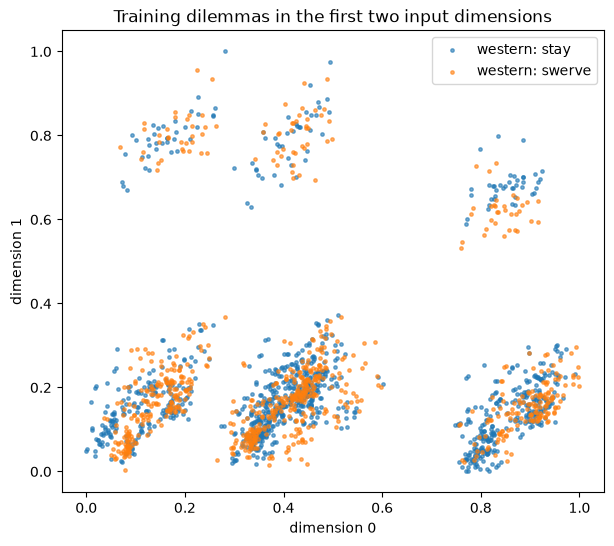

In [6]:
################################
### Visualise the embeddings ###
################################

# The first two of the 30 input dimensions, coloured by the western cluster's choice
y_w = train['y_western']
plt.figure(figsize=(7, 6))
for label, name in enumerate(CLASSES):
    mask = y_w == label
    plt.scatter(train['X'][mask, 0], train['X'][mask, 1], s=6, alpha=0.6, label=f'western: {name}')
plt.xlabel('dimension 0')
plt.ylabel('dimension 1')
plt.title('Training dilemmas in the first two input dimensions')
plt.legend()
plt.show()

In [7]:
####################################
### Describe the hyperrectangles ###
####################################

boxes = hyperrectangles['boxes']
widths = boxes[:, :, 1] - boxes[:, :, 0]

print(f'Hyperrectangles: {len(boxes)} (one per training dilemma)')
print(f'Points per box: median {int(np.median(hyperrectangles["n_points"]))}')
print(f'Width per dimension: median {np.median(widths):.3f}, largest {widths.max():.3f} (inputs are in [0, 1])')
print(f'Median box width relative to the spread of the dilemmas: {np.median(np.median(widths, axis=0) / train["X"].std(axis=0)):.2f}')

Hyperrectangles: 1836 (one per training dilemma)
Points per box: median 6
Width per dimension: median 0.134, largest 1.000 (inputs are in [0, 1])
Median box width relative to the spread of the dilemmas: 1.03


**The boxes are as wide as the spread of the dilemmas themselves.** Every dilemma uses the same
wording and differs only in its characters, so a typo in a character ("one cat" -> "one cta")
removes that character from the sentence's meaning as far as the embedding is concerned. That
moves the embedding about as far as switching to a different dilemma.

In [8]:
#####################################################
### Check whether the boxes contradict each other ###
#####################################################

# A box for a dilemma the western cluster answered 'stay' may intersect a box for one it
# answered 'swerve'. No network can give a point in both boxes both choices.
labels_w = hyperrectangles['label_western']
keep_w = labels_w >= 0
conflict = conflicting_boxes(boxes[keep_w], labels_w[keep_w])
print(f'Boxes that intersect a box with the opposite western choice: {conflict.mean():.1%}')

Boxes that intersect a box with the opposite western choice: 42.8%


**Almost half the boxes contradict another box.** Robustness on every box is therefore
impossible: the specification itself is inconsistent before any network is trained. Expect few
boxes to survive PGD, and adversarial training to resolve the conflicts by leaning towards the
more common choice. The coursework asks you to build boxes that contradict each other less.

***
# **BASE TRAINING**

In [9]:
##########################
### Set some variables ###
##########################

cluster = 'western'  # whose choices the worked example learns
input_size = 30
n_classes = 2
batch_size = 32
epochs = 50
pgd_steps = 10
beta = 0.1  # weight of the PGD loss in adversarial training (larger values collapse to one choice)
seed = 0

In [10]:
############################
### Pre-process the data ###
############################

def labelled(data, cluster):
    """Inputs and labels of the dilemmas the cluster did not tie on."""
    y = data[f'y_{cluster}']
    return data['X'][y >= 0], y[y >= 0]

X_train, y_train = labelled(train, cluster)
X_test, y_test = labelled(test, cluster)

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(buffer_size=2048, seed=seed).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)

In [11]:
########################
### Define the model ###
########################

def get_model(input_size, n_classes, summary=True):
    initializer = tf.keras.initializers.GlorotUniform(seed=42)
    model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(input_size,), name='input_features'),
            tf.keras.layers.Dense(128, activation='relu', kernel_initializer=initializer, name='dense_1'),
            tf.keras.layers.Dense(n_classes, activation='linear', kernel_initializer=initializer, name='output_layer')
        ])
    if summary:
        print(model.summary())
    return model

In [12]:
##########################
### Train a base model ###
##########################

tf.keras.utils.set_random_seed(seed)

optimizer = tf.keras.optimizers.Adam()
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
accuracy_fn = tf.keras.metrics.SparseCategoricalAccuracy()

model_base = get_model(input_size, n_classes)
model_base.compile(optimizer=optimizer, loss=loss_fn, metrics=[accuracy_fn])
model_base.fit(train_dataset, epochs=epochs, validation_data=test_dataset, verbose=2)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,226 (16.51 KB)

 Trainable params: 4,226 (16.51 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50


/home/melon501/source/JC-DAIR/moral-classification/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


58/58 - 0s - 8ms/step - loss: 0.6893 - sparse_categorical_accuracy: 0.5491 - val_loss: 0.6853 - val_sparse_categorical_accuracy: 0.5577
Epoch 2/50
58/58 - 0s - 897us/step - loss: 0.6748 - sparse_categorical_accuracy: 0.5834 - val_loss: 0.6849 - val_sparse_categorical_accuracy: 0.5708
Epoch 3/50
58/58 - 0s - 956us/step - loss: 0.6745 - sparse_categorical_accuracy: 0.5900 - val_loss: 0.6724 - val_sparse_categorical_accuracy: 0.5599
Epoch 4/50
58/58 - 0s - 869us/step - loss: 0.6685 - sparse_categorical_accuracy: 0.6020 - val_loss: 0.6666 - val_sparse_categorical_accuracy: 0.5752
Epoch 5/50
58/58 - 0s - 1ms/step - loss: 0.6599 - sparse_categorical_accuracy: 0.6189 - val_loss: 0.6652 - val_sparse_categorical_accuracy: 0.5861
Epoch 6/50
58/58 - 0s - 813us/step - loss: 0.6554 - sparse_categorical_accuracy: 0.6210 - val_loss: 0.6615 - val_sparse_categorical_accuracy: 0.6013
Epoch 7/50
58/58 - 0s - 971us/step - loss: 0.6500 - sparse_categorical_accuracy: 0.6358 - val_loss: 0.6520 - val_sparse_c

In [13]:
#############################################
### Define the accuracy per scenario type ###
#############################################

def print_metrics(model, data, cluster):
    y = data[f'y_{cluster}']
    keep = y >= 0
    y_pred = model.predict(data['X'][keep], verbose=0).argmax(axis=1)
    y, types = y[keep], data['scenario_type'][keep]
    print(f'Accuracy: {np.mean(y_pred == y):.4f}')

    # Each scenario type compares one attribute: age, fitness, gender, species, ...
    for t in np.unique(types):
        print(f'  {t:14s} {np.mean(y_pred[types == t] == y[types == t]):.4f} ({np.sum(types == t)} dilemmas)')

    # Confusion matrix: rows are the cluster's choice, columns the predicted one
    confusion = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y, y_pred):
        confusion[t, p] += 1
    print(f'Confusion matrix (rows: {cluster} choice, columns: predicted; order {CLASSES}):')
    print(confusion)

In [14]:
###########################################
### Calculate the accuracy on test data ###
###########################################

print_metrics(model_base, test, cluster)

Accuracy: 0.7691
  Age            0.7218 (133 dilemmas)
  Fitness        0.7385 (130 dilemmas)
  Gender         0.8426 (108 dilemmas)
  Random         0.7407 (27 dilemmas)
  Social Status  1.0000 (14 dilemmas)
  Species        0.7660 (47 dilemmas)
Confusion matrix (rows: western choice, columns: predicted; order ['stay', 'swerve']):
[[229  27]
 [ 79 124]]


In [15]:
#########################################################
### Calculate the accuracy on perturbed test dilemmas ###
#########################################################

def perturbed_accuracy(model, cluster):
    y = test[f'y_{cluster}'][test_perturbed['source']]
    keep = y >= 0
    return np.mean(model.predict(test_perturbed['X'][keep], verbose=0).argmax(axis=1) == y[keep])

print(f'Accuracy on perturbed test dilemmas: {perturbed_accuracy(model_base, cluster):.4f}')

Accuracy on perturbed test dilemmas: 0.6952


***
# **CULTURAL CLUSTERS**

The same dilemmas have different labels in different clusters. Training one classifier per
cluster shows whether each one learns its own cluster's preferences, especially on the dilemmas
where the clusters disagree.

In [16]:
############################################
### Train a base model for every cluster ###
############################################

cluster_models = {}
for c in CLUSTERS:
    tf.keras.utils.set_random_seed(seed)
    X_c, y_c = labelled(train, c)
    model = get_model(input_size, n_classes, summary=False)
    model.compile(optimizer=tf.keras.optimizers.Adam(), loss=loss_fn)
    model.fit(X_c, y_c, epochs=epochs, batch_size=batch_size, verbose=0)
    cluster_models[c] = model

In [17]:
##########################################################
### Compare the cluster models where clusters disagree ###
##########################################################

disputed = disagreement(test)
predictions = {c: cluster_models[c].predict(test['X'], verbose=0).argmax(axis=1) for c in CLUSTERS}

print(f"{'model':10s} {'test accuracy':>14s} {'on disputed dilemmas':>21s}")
for c in CLUSTERS:
    y = test[f'y_{c}']
    keep = y >= 0
    print(f'{c:10s} {np.mean(predictions[c][keep] == y[keep]):14.4f} {np.mean(predictions[c][disputed] == y[disputed]):21.4f}')

P = np.stack([predictions[c] for c in CLUSTERS], axis=1)
print(f'\nThe three models disagree on {np.mean(P.min(axis=1) != P.max(axis=1)):.1%} of all test dilemmas '
      f'and {np.mean(P[disputed].min(axis=1) != P[disputed].max(axis=1)):.1%} of the {disputed.sum()} disputed ones')

model       test accuracy  on disputed dilemmas
western            0.7865                0.7234
eastern            0.7686                0.8511
southern           0.7516                0.4681

The three models disagree on 23.1% of all test dilemmas and 40.4% of the 47 disputed ones


Accuracy on the disputed dilemmas shows how far each model follows its own cluster where the
cultures differ. Only a few dozen test dilemmas are disputed and most are close votes, so these
numbers are noisy. Whether a cluster's model is **robustly** aligned with its cluster is a
question for verification.

***
# **PGD**

Each hyperrectangle takes the western cluster's choice for the dilemma it was built from. PGD
starts at a random point inside a box and moves, within the box, in the direction that increases
the classification loss for the box's choice. The attack **succeeds** on a box if it finds a
point there that gets the other choice.

All boxes are attacked at once: each box has its own bounds, and the step size in each
dimension is proportional to the box's width in that dimension.

In [18]:
######################################
### Define the PGD attack function ###
######################################

def pgd_attack(model, boxes, labels, num_iter):
    """Perform a PGD attack inside a batch of hyperrectangles.

    Args:
        model: Trained Keras model.
        boxes: Hyperrectangles, shape (n, input_size, 2): [lower, upper] per dimension.
        labels: The choice (0 stay, 1 swerve) for each box.
        num_iter: Number of PGD iterations.

    Returns:
        Adversarial examples, one inside each box.
    """
    lower = tf.constant(boxes[:, :, 0], tf.float32)
    upper = tf.constant(boxes[:, :, 1], tf.float32)

    # Start from a random point inside each box
    x_adv = lower + tf.random.uniform(lower.shape) * (upper - lower)

    # Step size per dimension, proportional to the box width
    alpha = 2.5 * (upper - lower) / num_iter

    for i in range(num_iter):
        with tf.GradientTape() as tape:
            tape.watch(x_adv)
            predictions = model(x_adv)
            loss = tf.keras.losses.sparse_categorical_crossentropy(labels, predictions, from_logits=True)

        # Gradient ascent step in the direction that increases the loss
        gradients = tape.gradient(loss, x_adv)
        x_adv = x_adv + alpha * tf.sign(gradients)

        # Project back into the box (the boxes already lie inside [0, 1])
        x_adv = tf.clip_by_value(x_adv, lower, upper)

    return x_adv

In [19]:
#########################################
### Select the boxes and their labels ###
#########################################

# Boxes of dilemmas the western cluster did not tie on
box_labels_all = hyperrectangles[f'label_{cluster}']
box_keep = box_labels_all >= 0
boxes_c, box_labels = boxes[box_keep], box_labels_all[box_keep]
box_sentences = train['sentence'][hyperrectangles['source'][box_keep]]
print(f'{len(boxes_c)} boxes with a {cluster} label')

1834 boxes with a western label


In [20]:
#######################################
### Attack the base model using PGD ###
#######################################

tf.keras.utils.set_random_seed(seed)
x_adv = pgd_attack(model_base, boxes_c, box_labels, num_iter=20)

y_adv = model_base.predict(x_adv, verbose=0).argmax(axis=1)
pgd_survival_base = np.mean(y_adv == box_labels)
print(f'Boxes where PGD found no point with the other choice: {pgd_survival_base:.1%}')
print()
for i in np.where(y_adv != box_labels)[0][:3]:
    print(f'{cluster} choice {CLASSES[box_labels[i]]}, adversarial point {CLASSES[y_adv[i]]}: {box_sentences[i]}')

Boxes where PGD found no point with the other choice: 3.4%

western choice stay, adversarial point swerve: A self-driving car has sudden brake failure. If it stays on course, it will drive through the pedestrian crossing ahead, killing one cat. If it swerves, it will drive through the pedestrian crossing in the other lane, killing one male doctor.
western choice stay, adversarial point swerve: A self-driving car has sudden brake failure. If it stays on course, it will drive through the pedestrian crossing ahead, killing one cat. If it swerves, it will drive through the pedestrian crossing in the other lane, killing one female doctor.
western choice stay, adversarial point swerve: A self-driving car has sudden brake failure. If it stays on course, it will drive through the pedestrian crossing ahead, killing one cat. If it swerves, it will drive through the pedestrian crossing in the other lane, killing one male athlete.


***
# **ADVERSARIAL TRAINING**

As in ANTONIO and DAIR-course-NLP, every epoch first trains on the clean dilemmas, then runs PGD
inside every hyperrectangle and trains on the adversarial points, labelled with their box's
choice. `beta` weights the PGD loss.

Because so many boxes contradict each other, a large `beta` makes the network give the same
choice everywhere: with `beta = 1` it always stays. `beta = 0.1` keeps it making both choices.

In [21]:
################################################
### Define the adversarial training function ###
################################################

def adversarial_training(model, train_dataset, boxes, box_labels, optimizer, loss_fn, beta, num_iter, epochs):
    """
    Performs adversarial training with PGD points from the hyperrectangles.

    Args:
    model: The model to train.
    train_dataset: A TensorFlow dataset for training.
    boxes: Hyperrectangles to generate PGD points in.
    box_labels: The choice for each hyperrectangle.
    optimizer: The optimizer for model training.
    loss_fn: Loss function to use.
    beta: Weight of the PGD loss.
    num_iter: Number of PGD iterations for generating adversarial examples.
    epochs: Number of training epochs.

    Returns:
    model: The trained model.
    """

    @tf.function  # Compile the step into a graph for speed
    def train_step(x_batch, y_batch, weight):
        with tf.GradientTape() as tape:
            loss = weight * loss_fn(y_batch, model(x_batch, training=True))
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        return loss

    for epoch in range(epochs):
        start_time = time.time()

        # Train on the clean dilemmas
        for x_batch, y_batch in train_dataset:
            train_step(x_batch, y_batch, 1.0)

        # Generate one PGD point inside every hyperrectangle and train on them
        x_adv = pgd_attack(model, boxes, box_labels, num_iter)
        pgd_dataset = tf.data.Dataset.from_tensor_slices((x_adv, box_labels)).shuffle(2048).batch(batch_size)
        for x_batch, y_batch in pgd_dataset:
            train_step(x_batch, y_batch, beta)

        # Evaluate: test accuracy, and how many of this epoch's PGD points are still correct
        test_acc = np.mean(model.predict(X_test, verbose=0).argmax(axis=1) == y_test)
        pgd_acc = np.mean(model.predict(x_adv, verbose=0).argmax(axis=1) == box_labels)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1}/{epochs} -|- Test acc: {test_acc:.4f} -|- PGD acc: {pgd_acc:.4f} -|- Time: {(time.time() - start_time):.2f}s")

    return model

In [22]:
##################################
### Train an adversarial model ###
##################################

tf.keras.utils.set_random_seed(seed)

optimizer = tf.keras.optimizers.Adam()
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model_adv = get_model(input_size, n_classes)
model_adv = adversarial_training(model_adv, train_dataset, boxes_c, box_labels, optimizer, loss_fn,
                                 beta=beta, num_iter=pgd_steps, epochs=epochs)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,226 (16.51 KB)

 Trainable params: 4,226 (16.51 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50 -|- Test acc: 0.5577 -|- PGD acc: 0.5573 -|- Time: 0.70s
Epoch 10/50 -|- Test acc: 0.5643 -|- PGD acc: 0.5436 -|- Time: 0.21s
Epoch 20/50 -|- Test acc: 0.5708 -|- PGD acc: 0.5284 -|- Time: 0.22s
Epoch 30/50 -|- Test acc: 0.6144 -|- PGD acc: 0.4826 -|- Time: 0.21s
Epoch 40/50 -|- Test acc: 0.6492 -|- PGD acc: 0.4198 -|- Time: 0.22s
Epoch 50/50 -|- Test acc: 0.6645 -|- PGD acc: 0.3539 -|- Time: 0.22s


In [23]:
###########################################
### Calculate the accuracy on test data ###
###########################################

print_metrics(model_adv, test, cluster)
print(f'Accuracy on perturbed test dilemmas: {perturbed_accuracy(model_adv, cluster):.4f}')

Accuracy: 0.6645
  Age            0.5865 (133 dilemmas)
  Fitness        0.6385 (130 dilemmas)
  Gender         0.7500 (108 dilemmas)
  Random         0.5556 (27 dilemmas)
  Social Status  0.7857 (14 dilemmas)
  Species        0.7872 (47 dilemmas)
Confusion matrix (rows: western choice, columns: predicted; order ['stay', 'swerve']):
[[241  15]
 [139  64]]
Accuracy on perturbed test dilemmas: 0.6215


In [24]:
##############################################
### Attack the adversarial model using PGD ###
##############################################

tf.keras.utils.set_random_seed(seed)
x_adv_ADV = pgd_attack(model_adv, boxes_c, box_labels, num_iter=20)

pgd_survival_adv = np.mean(model_adv.predict(x_adv_ADV, verbose=0).argmax(axis=1) == box_labels)
print(f'Boxes where PGD found no point with the other choice: {pgd_survival_adv:.1%}')

Boxes where PGD found no point with the other choice: 13.6%


In [25]:
##############################
### Compare the two models ###
##############################

print(f"{'':32s} {'base':>8s} {'adversarial':>12s}")
print(f"{'Test accuracy':32s} {np.mean(model_base.predict(X_test, verbose=0).argmax(axis=1) == y_test):8.4f} "
      f"{np.mean(model_adv.predict(X_test, verbose=0).argmax(axis=1) == y_test):12.4f}")
print(f"{'Perturbed test accuracy':32s} {perturbed_accuracy(model_base, cluster):8.4f} {perturbed_accuracy(model_adv, cluster):12.4f}")
print(f"{'Boxes surviving PGD':32s} {pgd_survival_base:8.4f} {pgd_survival_adv:12.4f}")
print(f"{'Predicts swerve (test)':32s} {np.mean(model_base.predict(X_test, verbose=0).argmax(axis=1)):8.4f} "
      f"{np.mean(model_adv.predict(X_test, verbose=0).argmax(axis=1)):12.4f} (the {cluster} cluster swerves on {np.mean(y_test):.4f})")

                                     base  adversarial
Test accuracy                      0.7691       0.6645
Perturbed test accuracy            0.6952       0.6215
Boxes surviving PGD                0.0338       0.1363
Predicts swerve (test)             0.3290       0.1721 (the western cluster swerves on 0.4423)


Adversarial training makes more boxes survive PGD, but much of the gain comes from leaning towards
'stay': the boxes that survive are mostly boxes whose choice is 'stay'. Surviving PGD is also not
a guarantee, since PGD only tries a few points in each box. Whether a box is robust
**everywhere** is what `hyperrectangle-verification.ipynb` checks with Vehicle.

***
# **EXPORT TO ONNX**

Vehicle reads networks in ONNX format. Each network is written as a chain of `Gemm` (matrix
multiply plus bias) and `Relu` nodes, one per Dense layer.

In [26]:
#######################################
### Define the ONNX export function ###
#######################################

import onnx
from onnx import helper, numpy_helper, TensorProto
from onnx.reference import ReferenceEvaluator

def export_onnx(model, path):
    nodes, initializers, current = [], [], 'input'
    dense_layers = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Dense)]

    for i, layer in enumerate(dense_layers):
        W, b = layer.get_weights()
        initializers += [numpy_helper.from_array(W.astype(np.float32), f'W{i}'),
                         numpy_helper.from_array(b.astype(np.float32), f'b{i}')]

        # Dense layer: z = x @ W + b
        z = 'output' if i == len(dense_layers) - 1 else f'z{i}'
        nodes.append(helper.make_node('Gemm', [current, f'W{i}', f'b{i}'], [z]))
        current = z

        # ReLU on the hidden layers (the output layer is linear)
        if layer.get_config()['activation'] == 'relu':
            nodes.append(helper.make_node('Relu', [z], [f'a{i}']))
            current = f'a{i}'

    graph = helper.make_graph(
        nodes, 'dilemma_classifier',
        [helper.make_tensor_value_info('input', TensorProto.FLOAT, [1, input_size])],
        [helper.make_tensor_value_info('output', TensorProto.FLOAT, [1, n_classes])],
        initializers)
    onnx_model = helper.make_model(graph, opset_imports=[helper.make_opsetid('', 13)])
    onnx.checker.check_model(onnx_model)
    onnx.save(onnx_model, path)

In [27]:
####################################################
### Export the models and check they match Keras ###
####################################################

os.makedirs('models', exist_ok=True)
to_export = {f'{cluster}_base': model_base, f'{cluster}_pgd': model_adv,
             **{f'{c}_base': cluster_models[c] for c in CLUSTERS if c != cluster}}

for name, model in to_export.items():
    model.save(f'models/{name}.keras')
    export_onnx(model, f'models/{name}.onnx')

    # Run the ONNX network on every test dilemma and compare with Keras
    session = ReferenceEvaluator(f'models/{name}.onnx')
    y_onnx = np.array([session.run(None, {'input': x[None, :]})[0][0] for x in test['X']])
    difference = np.max(np.abs(y_onnx - model.predict(test['X'], verbose=0)))
    print(f'models/{name}.onnx: largest difference from Keras on the test set {difference:.2e}')

models/western_base.onnx: largest difference from Keras on the test set 3.58e-07
models/western_pgd.onnx: largest difference from Keras on the test set 2.68e-07
models/eastern_base.onnx: largest difference from Keras on the test set 5.96e-07
models/southern_base.onnx: largest difference from Keras on the test set 7.15e-07
